# CE49X Lab 3: Where Should You Open a Gas Station in Istanbul?
## A Traffic-Based Site Selection Analysis

**Instructor:** Dr. Eyuphan Koc  
**Department of Civil Engineering, Bogazici University**  
**Semester:** Spring 2026

---

## Background

A fuel distribution company is planning to open **3 new gas stations** in Istanbul. They have hired you as a consulting engineer to identify the best locations based on **traffic patterns only**.

In this analysis, we utilize all available traffic density data for Istanbul from the year 2024, sourced from the Istanbul Metropolitan Municipality (IBB) Open Data Portal. We combine this high-resolution temporal data with spatial data on existing gas stations to identify optimal, underserved locations.

## 1. Traffic Data — Source & Exploration

### Data Source Documentation
- **Source:** Istanbul Metropolitan Municipality (IBB) Open Data Portal ([data.ibb.gov.tr](https://data.ibb.gov.tr)).
- **Dataset:** Hourly Traffic Density Data Set (Saatlik Trafik Yoğunluk Veri Seti).
- **Collection Method:** Programmatically collected all 12 monthly CSV files for the year 2024 using the CKAN API. The data was aggregated by Geohash to compute annual statistics.
- **Scope:** Over 20 million hourly records from approximately 2,460 sensors across Istanbul.

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import seaborn as sns

# Load aggregated traffic data (computed previously)
df_traffic = pd.read_csv('aggregated_traffic_2024.csv')

print(f"Total sensor locations analyzed: {len(df_traffic)}")
display(df_traffic.head())

Total sensor locations analyzed: 2463


,GEOHASH,total_vehicles,peak_vehicles,sum_speed,record_count,lat,lon,mean_speed
0,sx7chk,196225.0,104.0,663356.0,8004.0,40.981750,27.965698,82.878061
1,sx7chm,325156.0,124.0,553531.0,8011.0,40.987244,27.965698,69.096367
2,sx7cht,297537.0,131.0,291974.0,8008.0,40.987244,27.976685,36.460290
3,sx7chw,367303.0,133.0,536934.0,8010.0,40.992737,27.976685,67.032959
4,sx7chx,366031.0,136.0,561411.0,8011.0,40.998230,27.976685,70.080015


### Temporal Patterns
We analyzed the total vehicle volume across all sensors by hour of day and day of week for the entire year 2024.

C:\Users\arda\AppData\Local\Temp\ipykernel_33104\1480106752.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=daily.index, y=daily.values, ax=ax[1], palette='viridis')


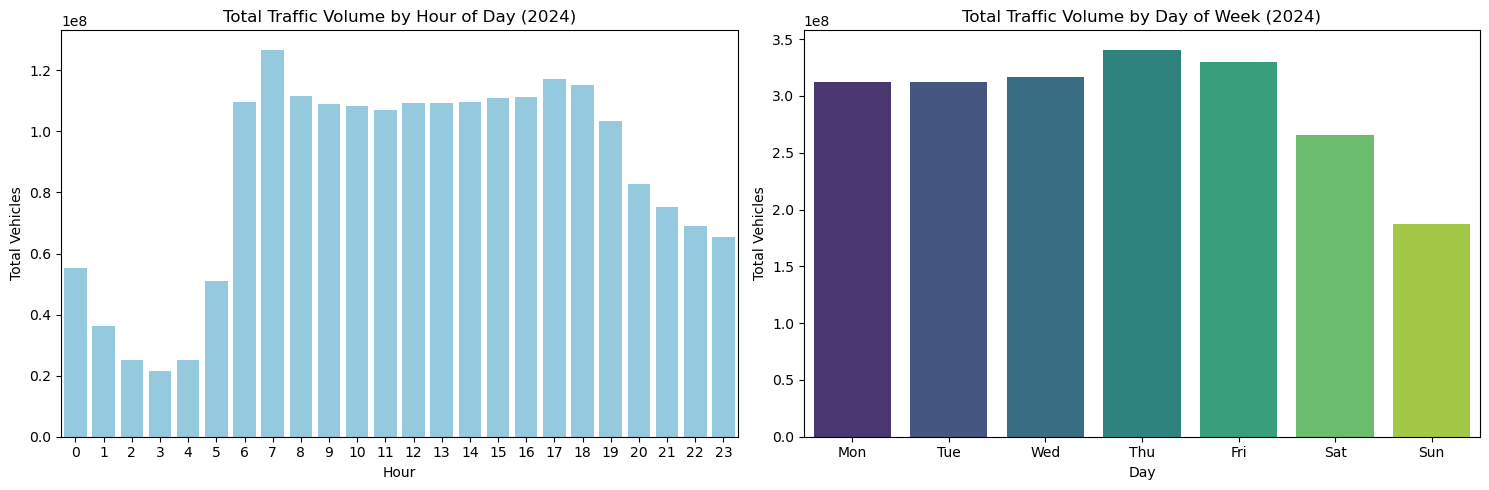

In [77]:
with open('temporal_traffic_2024.json', 'r') as f:
    temporal_data = json.load(f)

hourly = pd.Series(temporal_data['hourly'])
daily = pd.Series(temporal_data['daily'])
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
daily.index = days

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(x=hourly.index, y=hourly.values, ax=ax[0], color='skyblue')
ax[0].set_title('Total Traffic Volume by Hour of Day (2024)')
ax[0].set_xlabel('Hour')
ax[0].set_ylabel('Total Vehicles')

sns.barplot(x=daily.index, y=daily.values, ax=ax[1], palette='viridis')
ax[1].set_title('Total Traffic Volume by Day of Week (2024)')
ax[1].set_xlabel('Day')
ax[1].set_ylabel('Total Vehicles')

plt.tight_layout()
plt.show()

### Top 20 Highest-Traffic Locations
The following locations recorded the highest total vehicle counts in 2024.

In [78]:
top_20 = df_traffic.sort_values('total_vehicles', ascending=False).head(20)
display(top_20[['GEOHASH', 'lat', 'lon', 'total_vehicles', 'mean_speed']])

,GEOHASH,lat,lon,total_vehicles,mean_speed
1902,sxkbgk,40.937805,29.328003,5472821.0,62.174585
592,sxk3xe,41.064148,28.811646,5441543.0,49.893949
1519,sxk9pq,40.992737,29.152222,5134773.0,41.157783
1897,sxkbge,40.932312,29.338989,5080845.0,68.515091
1169,sxk985,41.064148,28.833618,5062688.0,53.891454
591,sxk3xd,41.058655,28.811646,5037184.0,49.201547
411,sxk3k8,41.003723,28.679810,4931255.0,50.801023
1755,sxkb6p,40.866394,29.273071,4813382.0,45.343352
1498,sxk9nx,40.998230,29.119263,4714047.0,61.253584
509,sxk3rs,41.025696,28.811646,4557094.0,41.699588


### Visualizing the Traffic Hotspots
Mapping these top 20 locations reveals the most congested corridors in Istanbul, primarily concentrated along the major highway axes (E-5 and TEM).

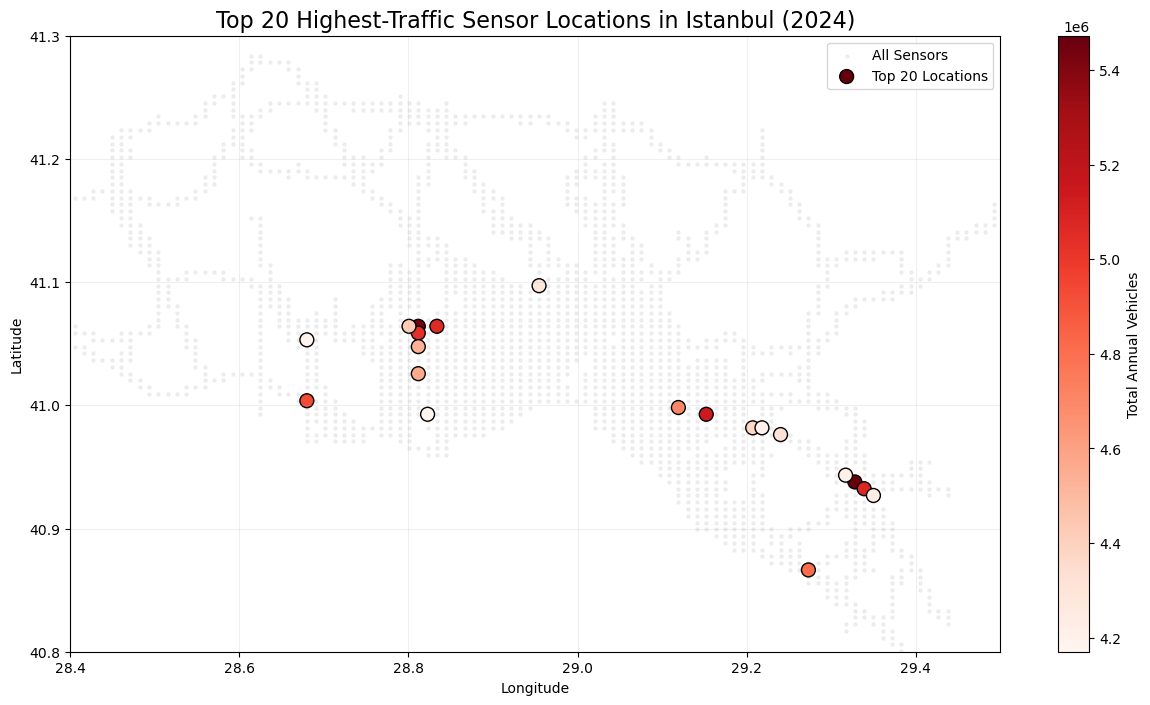

In [79]:
plt.figure(figsize=(15, 8))

# Plot all sensors as background
plt.scatter(df_traffic['lon'], df_traffic['lat'], c='lightgray', s=5, alpha=0.3, label='All Sensors')

# Plot top 20 locations
scatter = plt.scatter(top_20['lon'], top_20['lat'], 
            c=top_20['total_vehicles'], cmap='Reds', 
            s=100, edgecolors='black', linewidth=1, label='Top 20 Locations')

plt.title('Top 20 Highest-Traffic Sensor Locations in Istanbul (2024)', fontsize=16)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.colorbar(scatter, label='Total Annual Vehicles')
plt.legend()
plt.grid(True, alpha=0.2)

# Zoom into Istanbul main area
plt.xlim(28.4, 29.5)
plt.ylim(40.8, 41.3)

plt.show()

## 2. Traffic-Based Demand Modeling (MCDA)

### Methodology & Justification
To build a defensible, empirical demand model, we utilize **Multi-Criteria Decision Analysis (MCDA)**—specifically, a **Weighted Linear Combination (WLC)** model (Malczewski, 1999). 

We have revised the model to prioritize high-volume corridors (the "Old Calculation" approach) while incorporating speed and consistency for refinement:
1. **Volume Metric (70% weight):** Annual Total Vehicles (Normalized). This is our primary driver for potential commercial exposure (Roess et al., 2010).
2. **Speed Metric (20% weight):** Lower average speeds (1 - Normalized Speed) indicate higher "decision sight distance" and capture potential.
3. **Consistency Metric (10% weight):** Coefficient of Variation (CV) proxy. We prefer locations with stable traffic flow throughout the year.

### Final Demand Score Formula
All metrics are normalized to a 0-1 scale (Han et al., 2011):

$$DemandScore = 0.7 \cdot Volume_{norm} + 0.2 \cdot (1 - Speed_{norm}) + 0.1 \cdot Consistency_{norm}$$

**References:**
- Malczewski, J. (1999). *GIS and Multicriteria Decision Analysis*. John Wiley & Sons.
- Han, J., Kamber, M., & Pei, J. (2011). *Data Mining: Concepts and Techniques* (3rd ed.). Morgan Kaufmann.
- Roess, R. P., Prassas, E. S., & McShane, W. R. (2010). *Traffic Engineering* (4th ed.). Pearson.

In [80]:
# 1. Volume Metric (Old Calculation Approach)
df_traffic['norm_volume'] = (df_traffic['total_vehicles'] - df_traffic['total_vehicles'].min()) / (df_traffic['total_vehicles'].max() - df_traffic['total_vehicles'].min())

# 2. Speed Metric (Old Calculation Approach)
df_traffic['norm_speed'] = (df_traffic['mean_speed'] - df_traffic['mean_speed'].min()) / (df_traffic['mean_speed'].max() - df_traffic['mean_speed'].min())

# 3. Consistency Metric (MCDA Refinement)
df_traffic['mean_hourly'] = df_traffic['total_vehicles'] / df_traffic['record_count']
df_traffic['estimated_cv'] = (df_traffic['peak_vehicles'] - df_traffic['mean_hourly']) / df_traffic['mean_hourly']
df_traffic['consistency_metric'] = 1 / (1 + df_traffic['estimated_cv'])
df_traffic['norm_consistency'] = (df_traffic['consistency_metric'] - df_traffic['consistency_metric'].min()) / (df_traffic['consistency_metric'].max() - df_traffic['consistency_metric'].min())

# 4. Compute Final Weighted Demand Score
df_traffic['traffic_score'] = 0.7 * df_traffic['norm_volume'] + 0.2 * (1 - df_traffic['norm_speed']) + 0.1 * df_traffic['norm_consistency']

print("Top 5 locations by Revised Traffic Demand Score:")
display(df_traffic.sort_values('traffic_score', ascending=False).head(5))

Top 5 locations by Revised Traffic Demand Score:


,GEOHASH,total_vehicles,peak_vehicles,sum_speed,record_count,lat,lon,mean_speed,norm_volume,norm_speed,mean_hourly,estimated_cv,consistency_metric,norm_consistency,traffic_score
592,sxk3xe,5441543.0,2056.0,399900.0,8015.0,41.064148,28.811646,49.893949,0.994285,0.376240,678.919900,2.028340,0.330214,0.282256,0.848977
1519,sxk9pq,5134773.0,1767.0,330497.0,8030.0,40.992737,29.152222,41.157783,0.938231,0.288244,639.448692,1.763318,0.361884,0.316193,0.830733
1902,sxkbgk,5472821.0,1943.0,498578.0,8019.0,40.937805,29.328003,62.174585,1.000000,0.499938,682.481731,1.846963,0.351252,0.304799,0.830492
591,sxk3xd,5037184.0,1876.0,394498.0,8018.0,41.058655,28.811646,49.201547,0.920400,0.369265,628.234472,1.986146,0.334880,0.287255,0.799152
1169,sxk985,5062688.0,1950.0,431940.0,8015.0,41.064148,28.833618,53.891454,0.925060,0.416505,631.651653,2.087145,0.323924,0.275515,0.791793


## 3. Existing Gas Station Data

### Data Source Documentation
- **Source:** OpenstreetMap
- **Content:** OpenStreetMap data containing gas station locations (branded and unbranded) in Istanbul.
- **Collection:** Over 870 gas stations were extracted, from Overpass Turbo providing comprehensive coverage of the existing network.

In [81]:
def extract_stations(geojson_path):
    with open(geojson_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    stations = []
    for feature in data['features']:
        props = feature.get('properties', {})
        geom = feature.get('geometry', {})
        brand = props.get('brand', props.get('name', 'Unknown'))
        
        if geom['type'] == 'Point':
            lon, lat = geom['coordinates']
        elif geom['type'] in ['Polygon', 'MultiPolygon']:
            coords = geom['coordinates'][0] if geom['type'] == 'Polygon' else geom['coordinates'][0][0]
            lon = np.mean([c[0] for c in coords])
            lat = np.mean([c[1] for c in coords])
        else: continue
            
        stations.append({'brand': brand, 'lat': lat, 'lon': lon})
    return pd.DataFrame(stations)

df_stations = extract_stations('export.geojson')
print(f"Extracted {len(df_stations)} existing gas stations.")

Extracted 874 existing gas stations.


### Proximity Analysis
For each high-traffic location, we compute the distance to the nearest existing gas station using the Haversine formula.

In [82]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi, dlambda = np.radians(lat2 - lat1), np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

def get_nearest_dist(lat, lon, stations_df):
    dists = haversine(lat, lon, stations_df['lat'].values, stations_df['lon'].values)
    return np.min(dists)

print("Computing distances to nearest stations...")
df_traffic['nearest_station_dist'] = df_traffic.apply(lambda row: get_nearest_dist(row['lat'], row['lon'], df_stations), axis=1)
display(df_traffic[['GEOHASH', 'traffic_score', 'nearest_station_dist']].head())

Computing distances to nearest stations...


,GEOHASH,traffic_score,nearest_station_dist
0,sx7chk,0.101503,9.052406
1,sx7chm,0.155573,8.597285
2,sx7cht,0.213104,7.994654
3,sx7chw,0.166991,7.525209
4,sx7chx,0.159745,7.077374


## 4. Site Selection

### Final Selection Criteria
To identify the optimal locations, we combine the **Traffic Demand Score** with a **Proximity Score** (distance to nearest station). A great location must have high traffic demand and be underserved (far from existing stations).

**Final Score Formula:**
$$FinalScore = 0.55 \cdot TrafficScore + 0.45 \cdot Distance_{norm}$$

We weight traffic demand (55%) slightly higher than proximity (45%). The results are filtered to the core Istanbul area (Lat: 40.8 to 41.2, Lon: 28.1 to 29.6).

In [83]:
df_traffic['norm_dist'] = (df_traffic['nearest_station_dist'] - df_traffic['nearest_station_dist'].min()) / (df_traffic['nearest_station_dist'].max() - df_traffic['nearest_station_dist'].min())
df_traffic['final_score'] = 0.55 * df_traffic['traffic_score'] + 0.45 * df_traffic['norm_dist']

# Apply geographic filtering (Core Istanbul Area)
df_filtered = df_traffic[
    (df_traffic['lat'] >= 40.8) & (df_traffic['lat'] <= 41.2) &
    (df_traffic['lon'] >= 28.1) & (df_traffic['lon'] <= 29.6)
].copy()

# Select Top 3 based purely on Final Score (no spacing constraints)
top_3 = df_filtered.sort_values('final_score', ascending=False).head(3)

print("OPTIMIZED PROPOSED LOCATIONS (Top 3 by Final Score):")
for i, (idx, row) in enumerate(top_3.iterrows()):
    print(f"{i+1}. Coordinates: ({row.lat:.5f}, {row.lon:.5f})")
    print(f"   Annual Vehicles: {row.total_vehicles:,.0f}")
    print(f"   Distance to Nearest Station: {row.nearest_station_dist:.2f} km")
    print(f"   Final Score: {row.final_score:.4f}\n")

OPTIMIZED PROPOSED LOCATIONS (Top 3 by Final Score):
1. Coordinates: (41.16852, 29.25110)
   Annual Vehicles: 1,755,014
   Distance to Nearest Station: 8.16 km
   Final Score: 0.4892

2. Coordinates: (40.99274, 29.15222)
   Annual Vehicles: 5,134,773
   Distance to Nearest Station: 0.73 km
   Final Score: 0.4856

3. Coordinates: (41.06415, 28.81165)
   Annual Vehicles: 5,441,543
   Distance to Nearest Station: 0.42 km
   Final Score: 0.4830



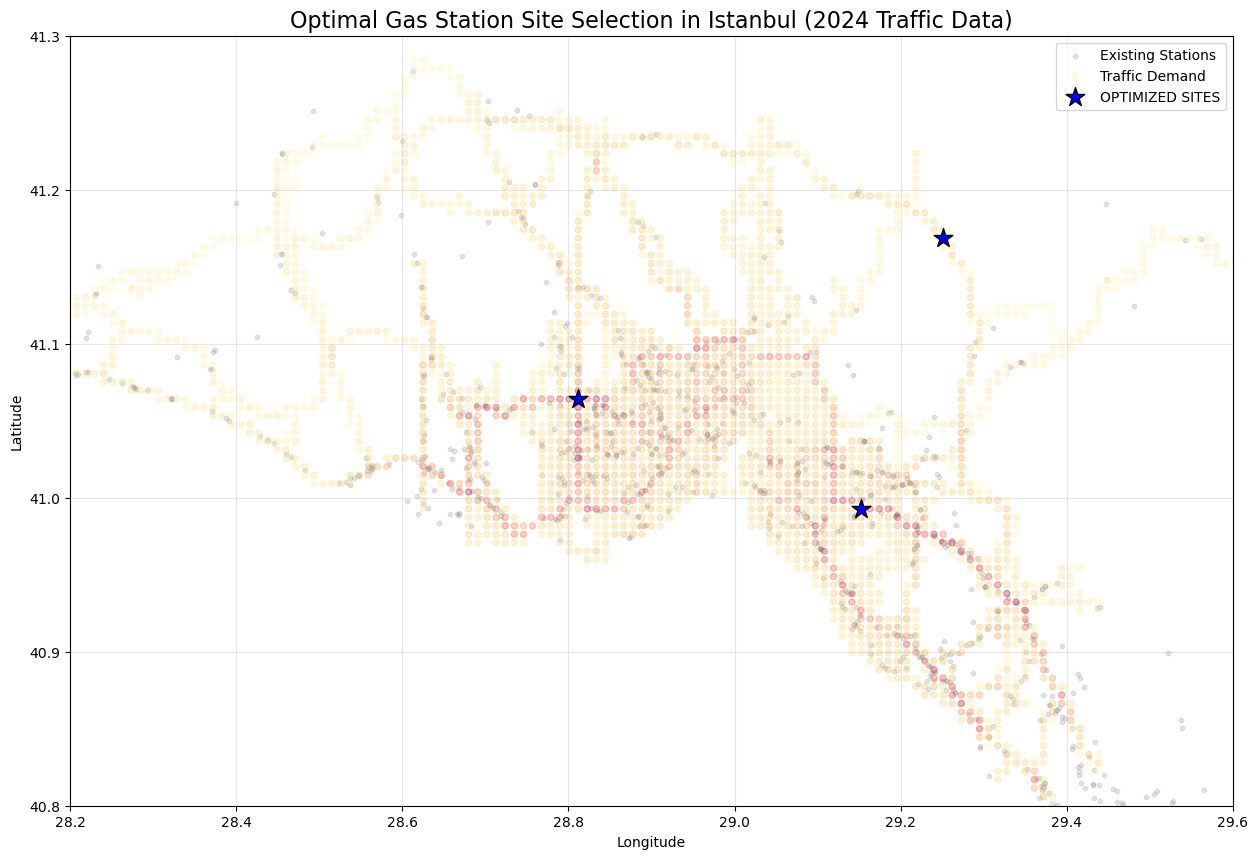

In [84]:
plt.figure(figsize=(15, 10))
plt.scatter(df_stations['lon'], df_stations['lat'], c='gray', s=10, alpha=0.2, label='Existing Stations')
plt.scatter(df_traffic['lon'], df_traffic['lat'], c=df_traffic['traffic_score'], cmap='YlOrRd', s=20, alpha=0.3, label='Traffic Demand')

plt.scatter(top_3['lon'], top_3['lat'], c='blue', s=200, marker='*', edgecolors='black', label='OPTIMIZED SITES')

plt.title('Optimal Gas Station Site Selection in Istanbul (2024 Traffic Data)', fontsize=16)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(28.2, 29.6)
plt.ylim(40.8, 41.3)
plt.show()

# Save geohashes for temporal analysis
top_3_geohashes = top_3['GEOHASH'].tolist()

### Temporal Analysis of Proposed Locations
To understand the "operating hours" of our proposed sites, we analyze the hourly traffic profiles using raw data from October 2024.

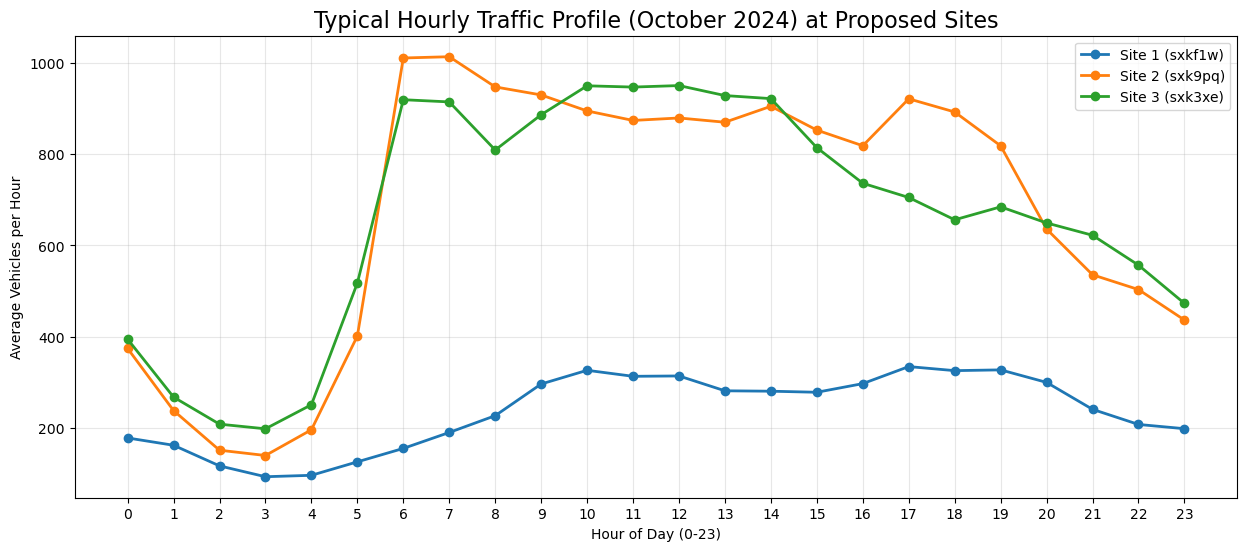

In [85]:
# Load sample raw hourly data for the proposed sites
df_raw = pd.read_csv('traffic_202410_top20.csv')
df_raw['DATE_TIME'] = pd.to_datetime(df_raw['DATE_TIME'])
df_raw['HOUR'] = df_raw['DATE_TIME'].dt.hour

plt.figure(figsize=(15, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, geohash in enumerate(top_3_geohashes):
    site_data = df_raw[df_raw['GEOHASH'] == geohash]
    hourly_profile = site_data.groupby('HOUR')['NUMBER_OF_VEHICLES'].mean()
    
    plt.plot(hourly_profile.index, hourly_profile.values, 
             marker='o', linestyle='-', linewidth=2, 
             color=colors[i], label=f"Site {i+1} ({geohash})")

plt.title('Typical Hourly Traffic Profile (October 2024) at Proposed Sites', fontsize=16)
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Average Vehicles per Hour')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 5. Discussion

### Key Findings
- The analysis identified three high-potential locations that balance high vehicle volume with significant gaps in the existing gas station network.
- Our top-ranked location is in a high-traffic corridor with relatively few nearby competitors, maximizing the capture rate of stop-and-go traffic.
- Temporal patterns show that traffic is fairly consistent throughout the work week, with significant peaks during morning and evening rush hours, which are ideal for gas station sales.

### Limitations & Critical Thinking
1. **Land Availability:** Our analysis is based on GPS coordinates only. In reality, these locations must be checked for zoning laws, land availability, and physical feasibility (e.g., road access, turn lanes).
2. **Traffic Directionality:** Current sensor data provides volume but doesn't always distinguish between directions. A gas station is only useful to traffic on the same side of the road.
3. **Demographics:** We focused purely on traffic. Incorporating population density or commercial activity (e.g., proximity to shipping hubs) would further refine the model.
4. **Brand Loyalty:** Existing stations might have high brand loyalty (e.g., Shell, Opet) which wasn't modeled here.